# Financial News Sentiment as a Short-Term Equity Signal

Author: Luu Nguyen Hanh Duyen  
Project: Equity Sentiment Alpha Study

This notebook investigates whether financial news sentiment predicts short-term stock returns.
We construct a cross-sectional sentiment signal and evaluate its predictive power using quintile portfolios and long–short strategies.

## 1. Research Question

Does financial news sentiment predict short-term stock returns?

### Economic intuition

Financial news introduces new information into the market.  
However, investors may not immediately incorporate this information into prices.

This delayed reaction may create predictable short-term return patterns.

We test whether stocks associated with more positive news sentiment outperform those with negative sentiment on the next trading day.

## 2. Dataset Overview

Universe: Active domestic common stocks traded on NASDAQ and NYSE
News source: Financial news API  
Data frequency: Daily aggregation

Key datasets:

- News articles with sentiment scores
- Daily stock prices and returns
- Liquidity metrics
- Sentiment signals aggregated at the stock-day level

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

con = duckdb.connect("../equity_sentiment/dev.duckdb")


### Universe statistics

In [2]:
query = """
SELECT
    COUNT(DISTINCT ticker) AS num_stocks,
    COUNT(DISTINCT date_t) AS num_days,
    COUNT(*) AS observations
FROM fct_signal_panel
"""

con.execute(query).df()

,num_stocks,num_days,observations
0,3056,82,64973


### News coverage over time

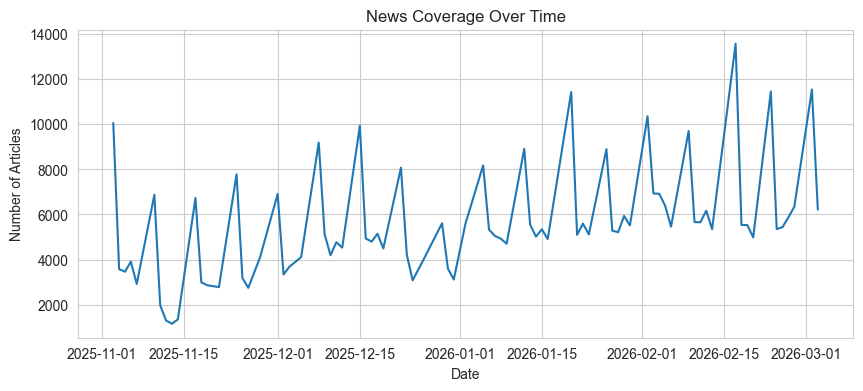

In [3]:
query = """
SELECT
    date_t,
    COUNT(*) AS news_articles
FROM stg_news
GROUP BY 1
ORDER BY 1
"""

news = con.execute(query).df()

plt.figure(figsize=(10,4))
plt.plot(news.date_t, news.news_articles)
plt.title("News Coverage Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Articles")
plt.show()

News coverage varies significantly across time due to differences in market activity and API coverage.

## 3. Sentiment Signal Construction

Article-level sentiment scores are aggregated to the stock-day level using a relevance-weighted average.

To reduce noise in the signal, the analysis focuses only on stock-days with meaningful news coverage.

Filtering rules:

• `has_sentiment_flag = 1`  
• `news_count > 1`

This ensures that the sentiment signal is constructed only when multiple articles discuss the same stock on a given day.

Trading signal: `Spread_t = R_{Q5,t+1} - R_{Q1,t+1}`

Where:
• Q5 = stocks with the most positive sentiment  
• Q1 = stocks with the most negative sentiment

The strategy goes long Q5 stocks and short Q1 stocks, holding the position for one trading day.

## 4. Sentiment Quintile Returns

Stocks are ranked daily by sentiment score and assigned into quintiles.

We test whether stocks in higher sentiment quintiles deliver higher next-day returns.

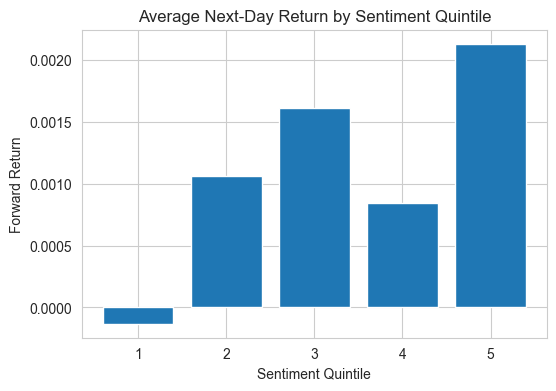

In [4]:
query = """
SELECT
    sentiment_quintile,
    AVG(forward_return_1d) AS avg_return
FROM fct_signal_panel
GROUP BY 1
ORDER BY 1
"""

quintile = con.execute(query).df()

plt.figure(figsize=(6,4))
plt.bar(quintile.sentiment_quintile, quintile.avg_return)

plt.title("Average Next-Day Return by Sentiment Quintile")
plt.xlabel("Sentiment Quintile")
plt.ylabel("Forward Return")

plt.show()

Returns generally increase with sentiment rank, suggesting that stocks associated with more positive sentiment tend to outperform those with negative sentiment.

## 5. Long–Short Portfolio Performance

We construct a daily long–short portfolio:

Long: Q5 (most positive sentiment)  
Short: Q1 (most negative sentiment)

The performance of this strategy is measured using the equal-weighted spread between the two portfolios.

In [5]:
query = """
SELECT
    date_t,
    spread_ew
FROM fct_signal_daily
ORDER BY 1
"""

spread = con.execute(query).df()
spread.head()

,date_t,spread_ew
0,2025-11-03,0.011807
1,2025-11-04,0.011591
2,2025-11-05,0.027152
3,2025-11-06,0.025702
4,2025-11-07,0.006652


### Cumulative returns

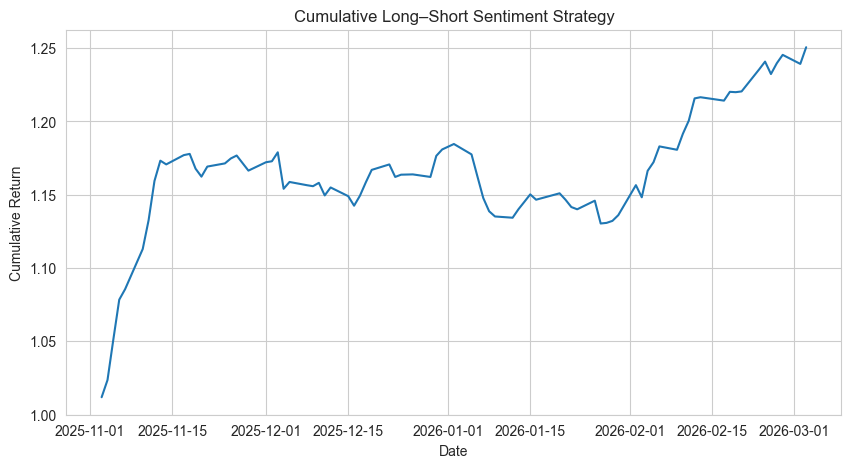

In [6]:
spread["cum_return"] = (1 + spread["spread_ew"]).cumprod()

plt.figure(figsize=(10,5))
plt.plot(spread.date_t, spread.cum_return)

plt.title("Cumulative Long–Short Sentiment Strategy")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")

plt.show()

The cumulative spread provides a visual representation of the profitability of the sentiment-based trading strategy.

## 6. Signal Stability
To evaluate the stability of the sentiment signal, we examine rolling statistics of the long-short spread.

In [7]:
query = """
SELECT
    date_t,
    spread_mean_20d,
    t_stat_20d
FROM fct_signal_rolling
ORDER BY 1
"""

rolling = con.execute(query).df()
rolling.head()

,date_t,spread_mean_20d,t_stat_20d
0,2025-12-01,0.008030,3.225346
1,2025-12-02,0.007467,2.977098
2,2025-12-03,0.007148,2.858358
3,2025-12-04,0.004735,1.790360
4,2025-12-05,0.003652,1.519175


### Rolling mean spread

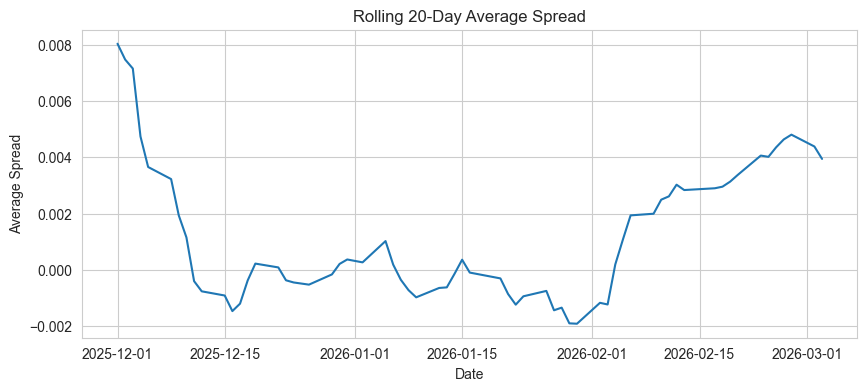

In [8]:
plt.figure(figsize=(10,4))
plt.plot(rolling.date_t, rolling.spread_mean_20d)

plt.title("Rolling 20-Day Average Spread")
plt.xlabel("Date")
plt.ylabel("Average Spread")

plt.show()

### Rolling t-statistic

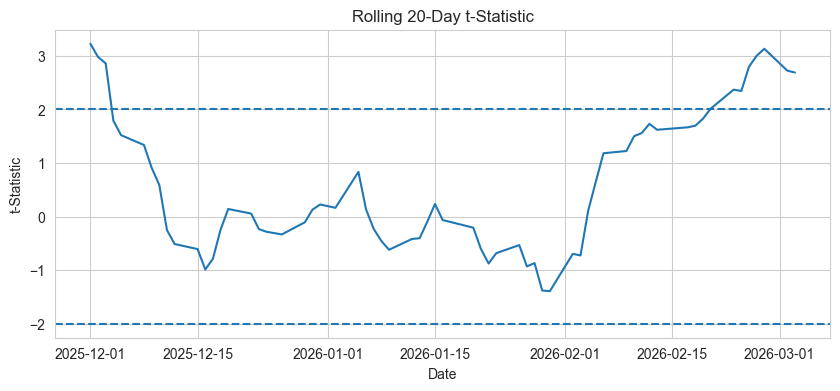

In [9]:
plt.figure(figsize=(10,4))
plt.plot(rolling.date_t, rolling.t_stat_20d)

plt.axhline(2, linestyle="--")
plt.axhline(-2, linestyle="--")

plt.title("Rolling 20-Day t-Statistic")
plt.xlabel("Date")
plt.ylabel("t-Statistic")

plt.show()

Rolling statistics help evaluate whether the sentiment signal remains consistent across time.

## 7. Liquidity Interaction
Information diffusion may vary across stocks with different liquidity levels.

We test whether the sentiment signal is stronger among lower-liquidity stocks.

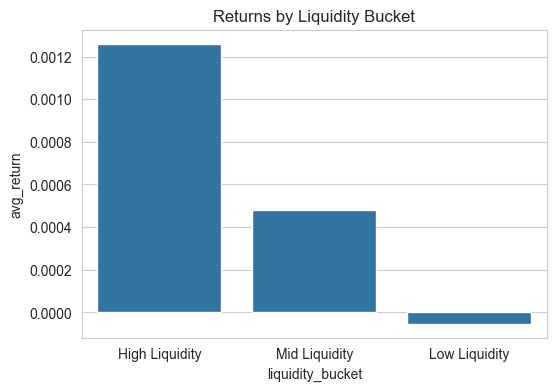

In [10]:
query = """
SELECT
    liquidity_bucket,
    AVG(forward_return_1d) AS avg_return
FROM fct_signal_panel
WHERE sentiment_quintile IN (1,5)
GROUP BY 1
"""

liq = con.execute(query).df()

plt.figure(figsize=(6,4))
sns.barplot(data=liq, x="liquidity_bucket", y="avg_return")

plt.title("Returns by Liquidity Bucket")
plt.show()

The sentiment effect is often stronger among lower-liquidity stocks, where information diffusion may occur more slowly.

## 8. News Intensity
Multiple news articles about the same stock may attract greater investor attention.

We test whether sentiment signals are stronger when more articles mention the stock.

In [11]:
query = """
SELECT
    news_count_bucket,
    AVG(forward_return_1d) AS avg_return
FROM fct_signal_panel
WHERE sentiment_quintile IN (1,5)
GROUP BY 1
"""

news_effect = con.execute(query).df()

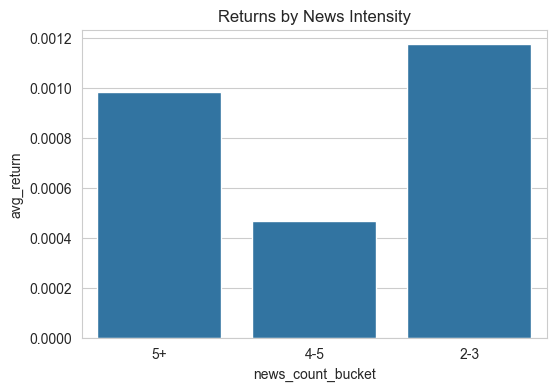

In [12]:
plt.figure(figsize=(6,4))
sns.barplot(data=news_effect, x="news_count_bucket", y="avg_return")

plt.title("Returns by News Intensity")
plt.show()

Stocks with higher news coverage tend to exhibit stronger sentiment effects.

## 9. Data Quality Considerations
To reduce noise in the sentiment signal, the analysis focuses only on stock-days with sufficient news coverage.

Filtering rules applied in the data warehouse:

• `has_sentiment_flag = 1`  
• `news_count > 1`

This ensures that sentiment signals are derived from multiple independent news articles rather than single-article noise.

## 10. Conclusion
This study investigates whether financial news sentiment predicts short-term stock returns.

Key findings:

• Stocks with more positive sentiment tend to outperform those with negative sentiment in the next trading day.

• The sentiment signal decays quickly, consistent with delayed market reaction to new information.

• The signal appears stronger when multiple news articles mention the same stock.

• Liquidity conditions may influence how quickly sentiment is incorporated into prices.

These results suggest that financial news sentiment may capture short-term market inefficiencies driven by delayed information processing.